In [1]:
using LinearAlgebra, SparseArrays, KrylovKit
using iTEBD
using Plots
using Test
using LaTeXStrings

In [2]:
function initial_state()
    A1 = reshape(Float64.([1.0, 0.0]), 1, 2, 1)
    A2 = reshape(Float64.([0.0, 1.0]), 1, 2, 1)
    Γ = [A1, A2]
    λ = [[1.0], [1.0]]
    return iMPS(Γ, λ, 2)
end

initial_state (generic function with 1 method)

In [ ]:
# function transfer_right_spectrum(ψ::iMPS, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
#     @assert length(ψ.Γ) == 2 "Only implemented for two-site unit cells."
#     Γ = iTEBD.tensor_group_2(ψ.Γ[1], ψ.Γ[2])

#     χ = size(Γ, 1)
#     d = size(Γ, 2)

#     map(X::Matrix) = reshape( reshape(Γ, χ*d, χ) * X, χ, d*χ ) * reshape(Γ, χ, d*χ)'

#     v0 = randn(ComplexF64, χ, χ)


#     arn = Arnoldi(; tol, eager, krylovdim)

#     TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

#     return v, μ
# end

# function transfer_left_spectrum(ψ::iMPS, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
#     @assert length(ψ.Γ) == 2 "Only implemented for two-site unit cells."
#     Γ = iTEBD.tensor_group_2(ψ.Γ[1], ψ.Γ[2])

#     χ = size(Γ, 1)
#     d = size(Γ, 2)

#     map(X::Matrix) = reshape(Γ, χ*d, χ)' * reshape( X* reshape(Γ, χ, χ*d), χ*d, χ )

#     v0 = randn(ComplexF64, χ, χ)

#     arn = Arnoldi(; tol, eager, krylovdim)

#     TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

#     return v, μ
# end

transfer_left_spectrum (generic function with 1 method)

In [ ]:
# function transfer_right_spectrum(ψ::iMPS, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
#     @assert length(ψ.Γ) == 2 "Only implemented for two-site unit cells."
#     Γ = iTEBD.tensor_group_2(ψ.Γ[1], ψ.Γ[2])

#     χ = size(Γ, 1)
#     d = size(Γ, 2)

#     map(X::Matrix) = sum( Γ[:,s,:] * X * Γ[:,s,:]' for s=1:d )

#     v0 = randn(ComplexF64, χ, χ)

#     arn = Arnoldi(; tol, eager, krylovdim)

#     TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

#     return v, μ
# end

# function transfer_left_spectrum(ψ::iMPS, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
#     @assert length(ψ.Γ) == 2 "Only implemented for two-site unit cells."
#     Γ = iTEBD.tensor_group_2(ψ.Γ[1], ψ.Γ[2])

#     χ = size(Γ, 1)
#     d = size(Γ, 2)

#     map(X::Matrix) = sum( Γ[:,s,:]' * X * Γ[:,s,:] for s=1:d )
    
#     v0 = randn(ComplexF64, χ, χ)

#     arn = Arnoldi(; tol, eager, krylovdim)

#     TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

#     return v, μ
# end

transfer_left_spectrum (generic function with 1 method)

In [5]:
function transfer_right_spectrum(Γ1::Array{<:Number,3}, Γ2::Array{<:Number,3}, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
    Γ = iTEBD.tensor_group_2(Γ1, Γ2)

    χ = size(Γ, 1)
    d = size(Γ, 2)

    map(X::Matrix) = sum( Γ[:,s,:] * X * Γ[:,s,:]' for s=1:d )

    v0 = randn(ComplexF64, χ, χ)

    arn = Arnoldi(; tol, eager, krylovdim)

    TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

    return v, μ
end

function transfer_left_spectrum(Γ1::Array{<:Number,3}, Γ2::Array{<:Number,3}, nvals::Int; tol=1e-8, krylovdim=40, eager=true)
    Γ = iTEBD.tensor_group_2(Γ1, Γ2)

    χ = size(Γ, 1)
    d = size(Γ, 2)

    map(X::Matrix) = sum( Γ[:,s,:]' * X * Γ[:,s,:] for s=1:d )
    
    v0 = randn(ComplexF64, χ, χ)

    arn = Arnoldi(; tol, eager, krylovdim)

    TT, v, μ, info = schursolve(map, v0, nvals, :LM, arn)

    return v, μ
end

transfer_left_spectrum (generic function with 1 method)

In [696]:
a = [0 0; 1 0]
adag = [0 1; 0 0]

function correlations(ψ::iMPS, range::Int)
    Γ1 = ψ.Γ[1]
    Γ2 = ψ.Γ[2]
    λ2 = Diagonal(ψ.λ[2])

    χ1, d, χ2 = size(Γ1)


    R2 = transfer_right_spectrum(Γ1, Γ2, 1)[1][1]
    R1 = transfer_right_spectrum(Γ2, Γ1, 1)[1][1]
    L = transfer_left_spectrum(Γ1, Γ2, 1)[1][1]


    A = reshape(Γ1, d*χ1, χ2)' * kron(a, L) * reshape(Γ1, d*χ1, χ2)
    B1 = reshape(Γ1, χ1, d*χ2) * kron(R1, transpose(adag)) * reshape(Γ1, χ1, d*χ2)'
    B2 = reshape(Γ2, χ2, d*χ1) * kron(R2, transpose(adag)) * reshape(Γ2, χ2, d*χ1)'

    corrs = zeros(ComplexF64, 2range+1)

    corrs[1] = tr(A * B2) / tr(L * R2)

    for i in 1:range
        A = A * reshape(Γ2, χ2, d*χ1)
        A = reshape(Γ2, χ2*d, χ1)' * reshape(A, χ2*d, χ1)

        corrs[2i] = tr(A * B1) / sum(tr(L * Γ1[:,i,:] * R1 * Γ1[:,i,:]' ) for i in 1:d)

        A = A * reshape(Γ1, χ1, d*χ2)
        A = reshape(Γ1, χ1*d, χ2)' * reshape(A, χ1*d, χ2)

        corrs[2i+1] = tr(A * B2) / tr(L * R2)
    end

    return corrs
end



correlations (generic function with 1 method)

In [759]:
# Create gate for iTEBD
const gate = begin
    dτ = 0.1
    x = [0 1
         1 0]
	y = [0 -1im
         1im 0]
	z = [1 0
         0 -1]
    SS = kron(x,x)+kron(y,y)+kron(z,z)
	H = -(1/4 * SS - 1/4*I)
    expH = exp(- dτ * H)
end

b = 128
tol = 1e-8
psi = initial_state()

T = 1000
interval = 50
range = 100

corrs = zeros(ComplexF64, T÷interval+1, 2range+1)

corrs[1, :] = correlations(psi, range)

for i=1:T
    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)
    applygate!(psi, gate, 2, 1; maxdim=b, cutoff=tol)

    if mod(i,interval) == 0
        corrs[i÷interval+1, :] = correlations(psi, range)    
    end
end

    # applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)

In [788]:
gate

4×4 Matrix{ComplexF64}:
 1.0+0.0im        0.0+0.0im        0.0+0.0im  0.0+0.0im
 0.0-0.0im   0.952419+0.0im  0.0475813+0.0im  0.0+0.0im
 0.0-0.0im  0.0475813-0.0im   0.952419+0.0im  0.0+0.0im
 0.0-0.0im        0.0-0.0im        0.0-0.0im  1.0+0.0im

In [790]:
0.95 * I + 0.05 * [1 0 0 0;
                  0 0 1 0;
                  0 1 0 0;
                  0 0 0 1]

4×4 Matrix{Float64}:
 1.0  0.0   0.0   0.0
 0.0  0.95  0.05  0.0
 0.0  0.05  0.95  0.0
 0.0  0.0   0.0   1.0

In [787]:
iTEBD.expect(psi, kron(a, adag), 1, 2)

0.25837653548098566

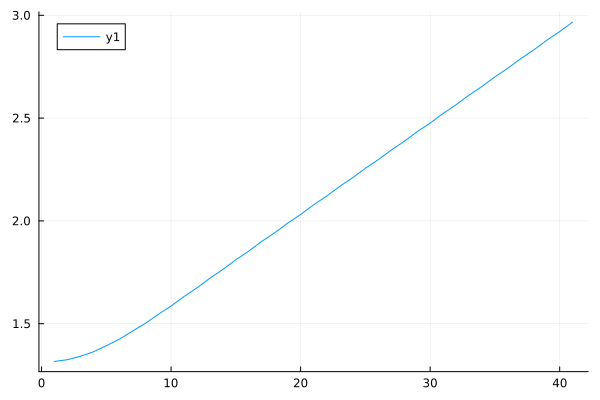

In [751]:
plot(-log.(abs.(corrs[2,:])))

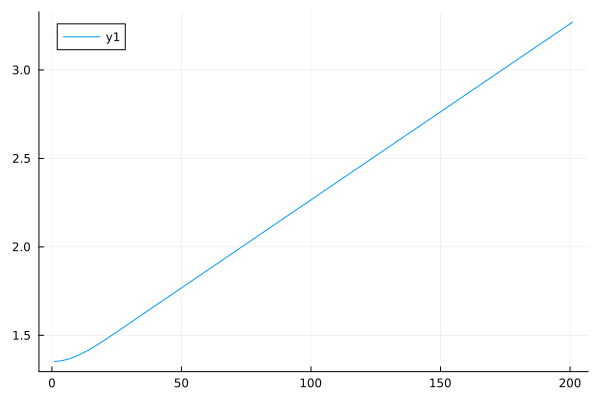

In [774]:
plot(-log.(abs.(corrs[20,:])))

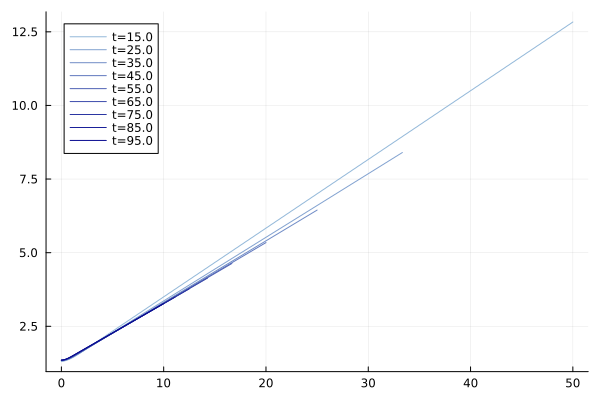

In [793]:
plt = plot()

colors = palette(:blues, size(corrs,1))

for t in 4:2:size(corrs,1)
    xs = collect(0:2range)
    xs /= t

    ys = -log.(abs.(corrs[t,:]))
    plot!(plt, xs, ys, label="t=$(interval/10*(t-1))", color=colors[t])
end
plt

In [690]:
corrs[:,1]

11-element Vector{ComplexF64}:
                  0.0 + 0.0im
 0.002728110645011753 - 1.512039299227439e-18im
 0.011514199493086763 - 1.8237335315419562e-10im
 0.026323884216617754 + 7.552878433879875e-11im
  0.04578357106285088 + 7.049861061033774e-12im
  0.06769268333465304 - 3.4275891226609434e-11im
  0.08988350521191359 + 7.79717603161336e-12im
  0.11081232942315887 - 1.1592569197252683e-10im
  0.12967323390802235 + 1.0859416088562022e-9im
   0.1462218765782736 - 3.62065643843948e-11im
   0.1605418699229283 + 3.81742029043592e-10im

In [659]:
tr(reshape(psi.Γ[1], d*χ1, χ2)' * kron(a, L) * reshape(psi.Γ[1], d*χ1, χ2) * reshape(psi.Γ[2], χ2, d*χ1) * kron(R, transpose(adag)) * reshape(psi.Γ[2], χ2, d*χ1)') / tr(L * R)

0.30546017063401737 + 5.60823329151401e-10im

In [558]:
# Create gate for iTEBD
const gate = begin
    dτ = 0.1
    x = [0 1
         1 0]
	y = [0 -1im
         1im 0]
	z = [1 0
         0 -1]
    SS = kron(x,x)+kron(y,y)+kron(z,z)
	H = -(1/4 * SS - 1/4*I)
    expH = exp(- dτ * H)
end

b = 128
tol = 1e-8
psi = initial_state()

T = 10

for i=1:T
    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)
    applygate!(psi, gate, 2, 1; maxdim=b, cutoff=tol)
end

    # applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)

In [559]:
χ1, d, χ2 = size(psi.Γ[1])
M = reshape(psi.Γ[1], χ1*d, χ2) * reshape(psi.Γ[2], χ2, d*χ1);
v, μ = transfer_right_spectrum(psi, 1)
println(μ)
R = v[1]

v, μ = transfer_left_spectrum(psi, 1)
println
L = v[1]


ComplexF64[0.9999395750241282 - 1.1811300131900343e-10im]
ComplexF64[0.9999395760829486 + 6.932497197901971e-10im]


In [560]:
T = reshape(M, χ1, d, d, χ1)                 # α,i,j,β
W = reshape(T, χ1*d*d, χ1)  # rows=(α,i,j), cols=β
Id2 = Matrix{eltype(L)}(I, d*d, d*d)

TL = W' * kron(Id2, L) * W   # == sum_{i,j} A_{ij}' * L * A_{ij}

TL2 = sum(T[:,i,j,:]' * L * T[:,i,j,:] for i=1:d for j=1:d)
maximum(abs.(TL .- TL2))  # should be small

1.5700924586837752e-16

In [585]:
function foo(T::Array{<:Number,3})
    χ1, d, χ2 = size(T)
    W = reshape(T, χ1*d, χ2)  # rows=(α,i), cols=β
    W = kron(a, diagm(ones(χ1))) * W
    W = reshape(W, χ1, d, χ2)
    return iTEBD.gtrm(T, W)
end

function bar(T::Array{<:Number,3})
    χ1, d, χ2 = size(T)
    W = reshape(T, χ1*d, χ2)  # rows=(α,i), cols=β
    W = kron(adag, diagm(ones(χ1))) * W
    W = reshape(W, χ1, d, χ2)
    return iTEBD.gtrm(T, W)
end

bar (generic function with 2 methods)

In [692]:
transpose(reshape(L, χ1^2)) * foo(psi.Γ[1]) * bar(psi.Γ[2]) * reshape(R, χ1^2) / (transpose(reshape(L, χ1^2)) * reshape(R, χ1^2))

0.3054601736829494 - 1.5455391177956228e-9im

In [612]:
T = iTEBD.trm(psi.Γ[2]) * iTEBD.trm(psi.Γ[1])

reshape(L, χ1^2)' * foo(psi.Γ[1]) * T*T*T * bar(psi.Γ[2]) * reshape(R, χ1^2) / (reshape(L, χ1^2)' * reshape(R, χ1^2))

0.006038888716406924 + 2.3309650010556013e-11im

In [675]:
reshape(L, χ1^2)' * foo(psi.Γ[1]) * T* bar(psi.Γ[2]) * reshape(R, χ1^2) / tr(L' * R)

0.08295689901698503 + 3.061286363187876e-10im

In [619]:
transpose(reshape(L, χ1^2)) * foo(psi.Γ[1]) * bar(psi.Γ[2]) * reshape(R, χ1^2) / tr(L * R)

0.30546017368294937 - 1.5455389982489998e-9im

In [658]:
tr(reshape(psi.Γ[1], d*χ1, χ2)' * kron(a, L) * reshape(psi.Γ[1], d*χ1, χ2) * reshape(psi.Γ[2], χ2, d*χ1) * kron(R, a) * reshape(psi.Γ[2], χ2, d*χ1)') / tr(L * R)

0.30546017063401737 + 5.60823329151401e-10im

In [632]:
tr(reshape(psi.Γ[1], d*χ1, χ2)' * kron(a, L) * reshape(psi.Γ[1], d*χ1, χ2) * reshape(psi.Γ[2], χ2, d*χ1) * kron(adag, R) * reshape(psi.Γ[2], χ2, d*χ1)') / tr(L * R)

-3.9128633912351595e-7 + 2.488531062904908e-13im

In [ ]:
tr(reshape(psi.Γ[1], χ1*d, χ2)' * kron(a, transpose(L)) * reshape(psi.Γ[1], χ1*d, χ2) *
    reshape(psi.Γ[2], χ2, d*χ1)       * kron(adag, R)             * reshape(psi.Γ[2], χ2, d*χ1)') / tr(L*R)

-3.9128633912351595e-7 + 2.488531062904908e-13im

In [633]:
transpose(reshape(L, χ1^2)) * iTEBD.gtrm(psi.Γ[1], reshape(kron(a, I(χ1)) * reshape(psi.Γ[1], χ1*d, χ2), χ1, d, χ2)) * iTEBD.gtrm(psi.Γ[2], reshape(kron(adag, I(χ2)) * reshape(psi.Γ[2], χ2*d, χ1), χ2, d, χ1)) * reshape(R, χ1^2) / tr(L*R)


0.30546017368294937 - 1.5455389982489998e-9im

In [656]:
reshape(psi.Γ[2], χ2, d*χ1) * kron(R, a) * reshape(psi.Γ[2], χ2, d*χ1)'

18×18 Matrix{ComplexF64}:
  -7.5275e-12+2.9593e-11im   …  -3.17144e-12+2.27808e-11im
  2.45837e-13-5.21859e-14im     -5.90252e-14-1.17736e-13im
  4.45435e-12-1.7222e-11im       8.68206e-13-8.02032e-12im
     0.101026+0.0463745im        -0.00140625-0.000645515im
  1.22126e-12-2.79091e-13im     -3.08553e-13-5.76784e-13im
  1.02706e-11-3.873e-11im    …  -2.89668e-12+8.40642e-12im
 -2.37079e-12+5.25862e-13im      5.84118e-13+1.13783e-12im
  6.60527e-16+1.0895e-15im      -5.21334e-17-8.49195e-16im
  1.25906e-12-1.69744e-13im       2.3879e-13+4.35166e-12im
  -0.00804673-0.00369373im       -0.00893973-0.00410364im
  1.22615e-12+1.41278e-12im  …  -8.09675e-15+5.62152e-12im
  0.000945822+0.000434165im        0.0150788+0.00692169im
  2.49764e-15+2.5687e-13im       5.29234e-13+6.39942e-14im
 -2.34742e-13+1.96665e-12im     -2.36702e-12-7.13327e-13im
   -0.0040621-0.00186464im        -0.0146223-0.00671216im
 -1.23815e-12-1.7534e-12im   …  -7.04475e-12-2.36576e-12im
 -3.07592e-11+6.93299e-11im      

In [657]:
reshape(bar(psi.Γ[2]) * reshape(R, χ1^2), χ2, χ2)

18×18 Matrix{ComplexF64}:
  -7.5275e-12+2.9593e-11im   …  -3.17144e-12+2.27808e-11im
  2.45837e-13-5.21859e-14im     -5.90252e-14-1.17736e-13im
  4.45435e-12-1.7222e-11im       8.68206e-13-8.02032e-12im
     0.101026+0.0463745im        -0.00140625-0.000645515im
  1.22126e-12-2.79091e-13im     -3.08553e-13-5.76784e-13im
  1.02706e-11-3.873e-11im    …  -2.89668e-12+8.40642e-12im
 -2.37079e-12+5.25862e-13im      5.84118e-13+1.13783e-12im
  6.60527e-16+1.0895e-15im      -5.21334e-17-8.49195e-16im
  1.25906e-12-1.69744e-13im       2.3879e-13+4.35166e-12im
  -0.00804673-0.00369373im       -0.00893973-0.00410364im
  1.22615e-12+1.41278e-12im  …  -8.09675e-15+5.62152e-12im
  0.000945822+0.000434165im        0.0150788+0.00692169im
  2.49764e-15+2.5687e-13im       5.29234e-13+6.39942e-14im
 -2.34742e-13+1.96665e-12im     -2.36702e-12-7.13327e-13im
   -0.0040621-0.00186464im        -0.0146223-0.00671216im
 -1.23815e-12-1.7534e-12im   …  -7.04475e-12-2.36576e-12im
 -3.07592e-11+6.93299e-11im      

In [652]:
reshape(psi.Γ[2], χ2, d*χ1) * kron(R, diagm(ones(2))) * reshape(psi.Γ[2], χ2, d*χ1)'

18×18 Matrix{ComplexF64}:
     0.231512+0.106272im     …   -0.00896621-0.0041158im
  8.93634e-12-3.78763e-11im      3.13889e-12-2.53752e-11im
   0.00835922+0.00383717im        0.00224777+0.0010318im
 -1.68814e-11+3.75869e-11im     -1.34005e-11-7.43856e-13im
 -5.05228e-13-1.19525e-11im     -1.38265e-12-7.81132e-13im
   -0.0115348-0.00529485im   …   -0.00266888-0.00122511im
 -2.24142e-11+1.11664e-10im      8.02016e-12-1.10293e-11im
  2.81518e-12-6.26946e-13im     -6.77432e-13-1.33024e-12im
   -0.0122078-0.00560379im       -0.00458884-0.00210644im
  1.79628e-11-9.92659e-12im     -8.57811e-12+2.05033e-10im
    -0.010133-0.00465138im   …   -0.00735291-0.00337524im
 -2.07981e-11+5.46283e-11im      7.02479e-12-6.88181e-11im
  4.18473e-12-5.53695e-12im      6.85588e-13+1.0171e-11im
   -0.0116077-0.00532834im        -0.0108902-0.00499898im
  6.62414e-11-1.24961e-10im     -1.07843e-11+1.98504e-10im
  -1.0676e-11+3.39833e-11im  …  -1.49895e-12-1.09298e-11im
 -2.05469e-12-7.96535e-12im      2.4830

In [650]:
reshape(iTEBD.trm(psi.Γ[2]) * reshape(R, χ1^2), χ2, χ2)

18×18 Matrix{ComplexF64}:
     0.231512+0.106272im     …   -0.00896621-0.0041158im
  8.93634e-12-3.78763e-11im      3.13889e-12-2.53752e-11im
   0.00835922+0.00383717im        0.00224777+0.0010318im
 -1.68814e-11+3.75869e-11im     -1.34005e-11-7.43856e-13im
 -5.05228e-13-1.19525e-11im     -1.38265e-12-7.81132e-13im
   -0.0115348-0.00529485im   …   -0.00266888-0.00122511im
 -2.24142e-11+1.11664e-10im      8.02016e-12-1.10293e-11im
  2.81518e-12-6.26946e-13im     -6.77432e-13-1.33024e-12im
   -0.0122078-0.00560379im       -0.00458884-0.00210644im
  1.79628e-11-9.92659e-12im     -8.57811e-12+2.05033e-10im
    -0.010133-0.00465138im   …   -0.00735291-0.00337524im
 -2.07981e-11+5.46283e-11im      7.02479e-12-6.88181e-11im
  4.18473e-12-5.53695e-12im      6.85588e-13+1.0171e-11im
   -0.0116077-0.00532834im        -0.0108902-0.00499898im
  6.62414e-11-1.24961e-10im     -1.07843e-11+1.98504e-10im
  -1.0676e-11+3.39833e-11im  …  -1.49895e-12-1.09298e-11im
 -2.05469e-12-7.96535e-12im      2.4830

In [647]:
reshape(psi.Γ[2], χ2, d*χ1) * kron(diagm(ones(χ1)), diagm(ones(2))) * reshape(psi.Γ[2], χ2, d*χ1)'

18×18 Matrix{Float64}:
  1.00047      -2.82552e-16   0.0385506    …  -6.54381e-12  -0.0268247
 -2.82552e-16   0.998399     -8.52247e-16     -3.03905e-11  -5.34195e-12
  0.0385506    -8.52247e-16   0.878112        -1.28035e-12   0.00834802
  7.27926e-16  -2.73334e-16  -5.32386e-15     -8.22622e-13  -6.48019e-13
  2.01231e-14  -0.00423052    4.75013e-14     -1.65456e-11  -3.13791e-12
 -0.0541832     6.62016e-15   0.0601406    …  -1.57553e-12  -0.00935469
  1.7209e-15   -0.0394228     1.03774e-14      3.64876e-11   7.15008e-12
 -2.37939e-15  -2.18031e-14  -1.50527e-15     -2.58878e-13  -8.22414e-13
 -0.0304593     7.82712e-14   0.0139349       -4.44131e-12  -0.0174607
 -5.17876e-14   1.73998e-13   1.62182e-14      4.7808e-13   -1.84784e-13
 -0.0314305     3.99798e-14   0.0256026    …  -8.42964e-13  -0.0212066
  3.00501e-14   4.52648e-12   3.47047e-14      3.22701e-13   1.82637e-13
 -7.29435e-14   0.0523575    -2.60175e-13      3.1127e-11    5.27961e-12
 -0.0331391     9.38289e-13  -0.0325

In [646]:
reshape(iTEBD.trm(psi.Γ[2]) * reshape(diagm(ones(χ1)), χ1^2), χ2, χ2)

18×18 Matrix{Float64}:
  1.00047      -2.82552e-16   0.0385506    …  -6.54381e-12  -0.0268247
 -2.82552e-16   0.998399     -8.52247e-16     -3.03905e-11  -5.34195e-12
  0.0385506    -8.52247e-16   0.878112        -1.28035e-12   0.00834802
  7.27926e-16  -2.73334e-16  -5.32386e-15     -8.22622e-13  -6.48019e-13
  2.01231e-14  -0.00423052    4.75013e-14     -1.65456e-11  -3.13791e-12
 -0.0541832     6.62016e-15   0.0601406    …  -1.57553e-12  -0.00935469
  1.7209e-15   -0.0394228     1.03774e-14      3.64876e-11   7.15008e-12
 -2.37939e-15  -2.18031e-14  -1.50527e-15     -2.58878e-13  -8.22414e-13
 -0.0304593     7.82712e-14   0.0139349       -4.44131e-12  -0.0174607
 -5.17876e-14   1.73998e-13   1.62182e-14      4.7808e-13   -1.84784e-13
 -0.0314305     3.99798e-14   0.0256026    …  -8.42964e-13  -0.0212066
  3.00501e-14   4.52648e-12   3.47047e-14      3.22701e-13   1.82637e-13
 -7.29435e-14   0.0523575    -2.60175e-13      3.1127e-11    5.27961e-12
 -0.0331391     9.38289e-13  -0.0325

In [596]:
tr(transpose(L)*R)

-0.21871347660951215 + 0.20255505705390328im

In [588]:
iTEBD.expect(psi, kron(a, adag), 1, 2)  # should be close to 0

0.3047959175430743

In [ ]:
reshape(L, χ1^2)' * reshape(R, χ1^2)

0.011011350026534137 - 0.2978974423510931im

In [579]:
reshape(L, χ1^2)' * iTEBD.trm(psi.Γ[1]) * iTEBD.trm(psi.Γ[2]) * reshape(R, χ1^2)

0.011010684673268363 - 0.2978794421026553im

In [610]:
all(abs.(iTEBD.trm(psi.Γ[1]) * iTEBD.trm(psi.Γ[2]) * reshape(R, χ1^2) .- reshape(R, χ1^2)) .< 1e-4)

true

In [605]:
all(abs.(transpose(reshape(L, χ1^2)) * iTEBD.trm(psi.Γ[1]) * iTEBD.trm(psi.Γ[2]) .- transpose(reshape(L, χ1^2))) .< 1e-4)

true

In [606]:
all(abs.(reshape(L, χ1^2)' * iTEBD.trm(psi.Γ[1]) * iTEBD.trm(psi.Γ[2]) .- reshape(L, χ1^2)') .< 1e-4)

true

In [603]:
reshape(L, χ1^2)'

1×324 adjoint(::Vector{ComplexF64}) with eltype ComplexF64:
 -0.376775-0.907828im  …  1.11634e-11-5.59102e-12im

In [604]:
transpose(reshape(L, χ1^2))

1×324 transpose(::Vector{ComplexF64}) with eltype ComplexF64:
 -0.376775+0.907828im  …  1.11634e-11+5.59102e-12im

In [519]:
ΓΓ = iTEBD.tensor_group_2(psi.Γ[1], psi.Γ[2])
all(abs.(sum( ΓΓ[:,s,:]' * L * ΓΓ[:,s,:] for s=1:d^2) .- L) .< 1e-5)

true

In [541]:
A = rand(3, 3)
B = rand(5, 5)
v = rand(3, 5)

A * v * B ≈ reshape(kron(B', A) * reshape(v, 15), 3, 5)

true

In [545]:
χ1, d, χ2 = size(psi.Γ[1])
M = reshape(psi.Γ[1], χ1*d, χ2) * reshape(psi.Γ[2], χ2, d*χ1);

sum(reshape(M' * kron([1 0; 0 1], L) * M, χ1, d, d, χ1)[:, i, i, :] for i in 1:d)

100×100 Matrix{ComplexF64}:
    0.0273671-0.36271im      …   7.67851e-16-3.25707e-15im
   1.24149e-9+2.75927e-10im      1.31764e-15-7.90314e-16im
   1.04593e-9+4.5681e-11im       1.71531e-16-7.27584e-16im
  -3.25207e-8+4.36785e-7im       -1.8335e-15-1.06192e-15im
   5.4267e-10+2.69878e-10im      1.48869e-15+9.8283e-16im
    0.0187301-0.24824im      …  -2.87259e-16+2.45473e-16im
   1.3307e-11+9.85085e-11im     -1.97845e-15+8.32866e-16im
   1.1083e-10-4.7313e-10im       1.45995e-15+6.71096e-16im
   2.38897e-8-3.15346e-7im       -1.5293e-16-9.41116e-16im
  1.15006e-10+3.00389e-10im      6.42637e-16-1.83812e-16im
             ⋮               ⋱  
 -1.19468e-13+2.44091e-14im      4.14066e-18+2.69908e-17im
 -1.07786e-12+6.96224e-14im     -2.36339e-16+6.77151e-17im
  1.93854e-13+1.8435e-12im       2.73185e-18-2.23529e-17im
 -4.16282e-14-1.72192e-14im      1.24218e-17-1.70559e-16im
 -5.35496e-13+1.21222e-14im  …    1.2524e-17-3.46591e-17im
   1.37198e-9-1.82397e-8im       3.86103e-17-1.6061e-16

In [522]:
tr(L * R)

-0.1660235647900249 - 0.052435873184358675im

In [485]:
all(abs.(M' * kron(L,[1 0; 0 1])' * M .- kron(L, [1 0; 0 1]))' .< 1e-8)

false

In [496]:
v, μ = transfer_right_spectrum(psi, 1)
println(μ)
R = v[1]

v, μ = transfer_left_spectrum(psi, 1)
L = v[1]

tr(L * R)

ComplexF64[1.0000015127299982 - 1.0880987381679064e-10im]


0.0841275997364559 - 0.15243323667854378im

In [494]:
μ

1-element Vector{ComplexF64}:
 1.0000015121574535 + 3.094709871885945e-10im

In [437]:
χ1, d, χ2 = size(psi.Γ[1])
M = reshape(psi.Γ[1], χ1*d, χ2) * reshape(psi.Γ[2], χ2, d*χ1);
M1 = reshape(psi.Γ[1], χ1*d, χ2)
M2 = reshape(psi.Γ[2], χ2, d*χ1);

In [470]:
iTEBD.expect(psi, kron(adag, a), 1, 2)

0.2680534773863877

In [421]:
tr(L * R)

0.0959196256202123 + 0.14530234029609435im

In [ ]:
ΓΓ = iTEBD.tensor_group_2(psi.Γ[2], psi.Γ[1]);
sum(tr(kron([1 0; 0 1], L) * M1 * ΓΓ[:,i,:] * M2 * kron(R, [1 0; 0 1]) * M2' * ΓΓ[:,i,:]' * M1') for i in 1:d^2)

0.09591991585136211 + 0.14530277994819918im

In [462]:
sum(tr(kron([1 0; 0 1], L) * M1 * ΓΓ[:,i,:] * ΓΓ[:,j,:] * M2 * kron(R, [1 0; 0 1]) * M2' * ΓΓ[:,j,:]' * ΓΓ[:,i,:]' * M1') for i in 1:d^2 for j in 1:d^2)

0.0959200609672663 + 0.1453029997747504im

In [453]:
ΓΓ = iTEBD.tensor_group_2(psi.Γ[2], psi.Γ[1]);
sum(tr(kron(a, L)' * M1 * M2 * kron(R, adag) * M2' * M1'))

-0.018647879799621486 - 0.04278956694091564im

In [455]:
ΓΓ = iTEBD.tensor_group_2(psi.Γ[2], psi.Γ[1]);
sum(tr(kron(a, L)' * M1 * ΓΓ[:,i,:] * M2 * kron(R, adag) * M2' * ΓΓ[:,i,:]' * M1') for i in 1:d^2)

-0.018184133216870603 - 0.04172545042114123im

In [456]:
(-0.018184133216870603 - 0.04172545042114123im)/(-0.018647879799621486 - 0.04278956694091564im)

0.9751314027472537 - 6.918398834626196e-10im

In [468]:
sum(tr(kron(L,a) * M * kron(adag, R) * M))/tr(L * R)

0.17954222823289748 - 1.0847901069191751e-10im

In [448]:
ΓΓ = iTEBD.tensor_group_2(psi.Γ[2], psi.Γ[1]);
sum(tr(kron(a, L)' * M1 * ΓΓ[:,i,:] * ΓΓ[:,j,:] * M2 * kron(R, adag) * M2' * ΓΓ[:,j,:]' * ΓΓ[:,i,:]' * M1') for i in 1:d^2 for j in 1:d^2)

-0.017275577376448775 - 0.039640671225831085im

In [445]:
tr(kron(a, L)' * M * kron(R, adag) * M')

-0.018647879799621493 - 0.04278956694091563im

In [ ]:
tr(kron(a, L)' * M * kron(R, adag) * M') / tr(kron([1 0; 0 1], L)' * M * kron(R, [1 0; 0 1]) * M')

0.2680897316628999 - 2.5331387604687624e-10im

In [425]:
tr(kron([1 0; 0 1], L)' * M * kron(R, [1 0; 0 1]) * M')

-0.06955835139049045 - 0.15960912300938096im

In [411]:
tr(L * R)

0.17410727922886543 + 0.0im

In [388]:
L = iTEBD.steady_mat(iTEBD.tensor_group(psi.Γ); dir=:l)
R = iTEBD.steady_mat(iTEBD.tensor_group(psi.Γ); dir=:r)

tr(L*R)

0.17410727922886543 + 0.0im

In [ ]:
krylov_eigen

2×2 Matrix{Int64}:
 0  0
 0  0

In [ ]:
Γ1 = psi.Γ[1]
Γ2 = psi.Γ[2]
λ2 = Diagonal(psi.λ[2])

χ1, d, χ2 = size(Γ1)


L = reshape(Γ1, d*χ1, χ2)' * kron(a, Lboundary) * reshape(Γ1, d*χ1, χ2)
# R1 = reshape(Γ1, χ1, d*χ2) * kron(adag, diagm(ones(χ2))) * reshape(Γ1, χ1, d*χ2)'
R2 = reshape(Γ2, χ2, d*χ1) * kron(adag, Rboundary) * reshape(Γ2, χ2, d*χ1)'

MethodError: MethodError: no method matching gtrm(::iMPS{ComplexF64})
The function `gtrm` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  gtrm(::iMPS, !Matched::iMPS)
   @ iTEBD ~/.julia/packages/iTEBD/3oT3B/src/iMPS.jl:124
  gtrm(!Matched::AbstractArray{<:Number, 3}, !Matched::AbstractArray{<:Number, 3})
   @ iTEBD ~/.julia/packages/iTEBD/3oT3B/src/TensorAlgebra.jl:235
  gtrm(!Matched::AbstractVector{<:AbstractArray{<:Number, 3}}, !Matched::AbstractVector{<:AbstractArray{<:Number, 3}})
   @ iTEBD ~/.julia/packages/iTEBD/3oT3B/src/TensorAlgebra.jl:253


In [270]:
a = [0 0; 1 0]
adag = [0 1; 0 0]

function correlations(ψ::iMPS, range::Int)
    Γ1 = ψ.Γ[1]
    Γ2 = ψ.Γ[2]
    λ2 = Diagonal(ψ.λ[2])

    χ1, d, χ2 = size(Γ1)


    Rboundary = transfer_right_spectrum(ψ, 1)[1][1]
    Rboundary = transfer_right_spectrum(ψ, 1)[1][1]
    Lboundary = transfer_left_spectrum(ψ, 1)[1][1]


    L = reshape(Γ1, d*χ1, χ2)' * kron(a, Lboundary) * reshape(Γ1, d*χ1, χ2)
    # R1 = reshape(Γ1, χ1, d*χ2) * kron(adag, diagm(ones(χ2))) * reshape(Γ1, χ1, d*χ2)'
    R2 = reshape(Γ2, χ2, d*χ1) * kron(adag, Rboundary) * reshape(Γ2, χ2, d*χ1)'

    corrs = zeros(ComplexF64, 2*range+1)

    corrs[1] = tr(L * R2)


    for i in 1:2:range
        L = L * reshape(Γ2, χ2, d*χ1)
        L = reshape(Γ2, χ2*d, χ1)' * reshape(L, χ2*d, χ1)

        # corrs[2i] = tr(L * R1)

        L = L * reshape(Γ1, χ1, d*χ2)
        L = reshape(Γ1, χ1*d, χ2)' * reshape(L, χ1*d, χ2)

        corrs[2i+1] = tr(L * R2)
    end

    return corrs
end


correlations (generic function with 1 method)

In [271]:
# a = [0 0; 1 0]
# adag = [0 1; 0 0]

# function correlations(ψ::iMPS, range::Int)
#     Γ1 = ψ.Γ[1]
#     Γ2 = ψ.Γ[2]
#     λ2 = Diagonal(ψ.λ[2])

#     χ1, d, χ2 = size(Γ1)

#     L = reshape(Γ1, d*χ1, χ2)' * kron(a, Diagonal(λ2)^2) * reshape(Γ1, d*χ1, χ2)
#     R1 = reshape(Γ1, χ1, d*χ2) * kron(adag, diagm(ones(χ2))) * reshape(Γ1, χ1, d*χ2)'
#     R2 = reshape(Γ2, χ2, d*χ1) * kron(adag, diagm(ones(χ1))) * reshape(Γ2, χ2, d*χ1)'

#     corrs = zeros(ComplexF64, 2*range+1)

#     corrs[1] = tr(L * R2)

#     for i in 1:2:range
#         L = L * reshape(Γ2, χ2, d*χ1)
#         L = reshape(Γ2, χ2*d, χ1)' * reshape(L, χ2*d, χ1)

#         corrs[2i] = tr(L * R1)

#         L = L * reshape(Γ1, χ1, d*χ2)
#         L = reshape(Γ1, χ1*d, χ2)' * reshape(L, χ1*d, χ2)

#         corrs[2i+1] = tr(L * R2)
#     end

#     return corrs
# end


In [379]:
# Create gate for iTEBD
const gate = begin
    dτ = 0.1
    x = [0 1
         1 0]
	y = [0 -1im
         1im 0]
	z = [1 0
         0 -1]
    SS = kron(x,x)+kron(y,y)+kron(z,z)
	H = -(1/4 * SS - 1/4*I)
    expH = exp(- dτ * H)
end

b = 128
tol = 1e-8
psi = initial_state()

T = 200

for i=1:T
    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)
    applygate!(psi, gate, 2, 1; maxdim=b, cutoff=tol)
end

    # applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)

In [273]:
    Rboundary = transfer_right_spectrum(psi, 1)[1]
    Lboundary = transfer_left_spectrum(psi, 1)[1]


1-element Vector{Matrix{ComplexF64}}:
 [-0.4212900942852231 - 0.711091402370871im 1.6540193978335446e-9 + 1.5666636708982715e-9im … 3.4457591467418668e-15 + 7.918365214776565e-14im -6.307926622794929e-14 - 8.882031302118986e-14im; -6.127851508240764e-9 - 6.285465221704585e-9im -0.26373832522921337 - 0.44516132257457847im … 1.607225958658968e-13 + 2.8153682894726375e-14im -6.374702339003238e-14 - 1.232882790192141e-13im; … ; 2.2537317099018033e-13 - 2.1681943901985417e-14im -2.4015262351192797e-13 - 2.138631829171699e-13im … 2.419938001066881e-13 - 1.918245981737893e-13im -3.809407494045096e-15 - 2.3682075794273377e-13im; 1.0510513879706614e-13 + 9.788516999781301e-14im 6.754870032862209e-14 + 2.8421445237736484e-13im … 1.4800409052664633e-13 - 1.696867084107359e-14im -3.706249528282471e-14 + 8.252740649792816e-14im]

In [280]:
tr(Lboundary[1] * Rboundary[1])

0.1523989511060822 + 0.08418969336107184im

In [275]:
psi.Γ[1]

100×2×102 Array{ComplexF64, 3}:
[:, :, 1] =
    -0.747775+0.0im  -1.04361e-13+0.0im
  3.49156e-14+0.0im     -0.828369+0.0im
 -5.93576e-14+0.0im  -4.40566e-14+0.0im
  -4.4746e-14+0.0im  -4.60879e-15+0.0im
  1.70481e-14+0.0im  -6.74541e-14+0.0im
     0.427655+0.0im  -1.42109e-13+0.0im
  1.27622e-13+0.0im      0.346315+0.0im
 -1.56123e-14+0.0im   7.43087e-14+0.0im
 -2.77397e-14+0.0im  -5.65189e-14+0.0im
 -1.40922e-13+0.0im   7.03265e-14+0.0im
             ⋮       
 -6.43571e-15+0.0im    0.00117928+0.0im
  -0.00223311+0.0im   1.31701e-11+0.0im
  -1.1425e-14+0.0im  -5.80365e-11+0.0im
 -6.39717e-15+0.0im   2.17237e-11+0.0im
 -1.22572e-13+0.0im    0.00207419+0.0im
 -6.29153e-15+0.0im  -4.69201e-11+0.0im
 -3.29128e-12+0.0im  -1.73986e-10+0.0im
 -6.19827e-12+0.0im   3.15006e-12+0.0im
 -1.85825e-11+0.0im  -3.75628e-12+0.0im

[:, :, 2] =
 -3.87025e-14+0.0im      0.663294+0.0im
 -8.46241e-14+0.0im  -1.06077e-13+0.0im
     0.888361+0.0im   -1.8112e-14+0.0im
 -1.94108e-14+0.0im  -8.19746e-14+0.0im
 

In [281]:
correlations(psi, 20)

41-element Vector{ComplexF64}:
   6.534183023384077e-8 - 7.928248604132106e-8im
                    0.0 + 0.0im
 -4.4073404934032347e-8 + 5.348137083939607e-8im
                    0.0 + 0.0im
                    0.0 + 0.0im
                    0.0 + 0.0im
  1.3816683610032414e-8 - 1.6766091614096556e-8im
                    0.0 + 0.0im
                    0.0 + 0.0im
                    0.0 + 0.0im
                        ⋮
                    0.0 + 0.0im
                    0.0 + 0.0im
  2.1430991578494524e-8 - 2.6005200725583915e-8im
                    0.0 + 0.0im
                    0.0 + 0.0im
                    0.0 + 0.0im
   1.919128090342882e-8 - 2.3287447687989653e-8im
                    0.0 + 0.0im
                    0.0 + 0.0im

In [176]:
Γ1, λ1 = psi[1]
Γ2, λ2 = psi[2]

Γ = iTEBD.tensor_rmul!(deepcopy(Γ1), λ1)
M = reshape(Γ, size(Γ1)[1], size(Γ1)[2]*size(Γ1)[3])
@test norm(M * M' - I) ≈ 0 atol = 1e-12

Test Passed

In [178]:
Γ1, λ1 = psi[1]
Γ2, λ2 = psi[2]

Γ = iTEBD.tensor_rmul!(deepcopy(Γ2), λ2)
M = reshape(Γ, size(Γ2)[1], size(Γ2)[2]*size(Γ2)[3])
@test norm(M * M' - I) ≈ 0 atol = 1e-12

Test Failed at /Users/jhauser/Code/U1_SWSSB/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X53sZmlsZQ==.jl:6
  Expression: ≈(norm(M * M' - I), 0, atol = 1.0e-12)
   Evaluated: 0.7770150066755248 ≈ 0 (atol=1.0e-12)



Test.FallbackTestSetException: Test.FallbackTestSetException("There was an error during testing")

In [350]:

# Create gate for iTEBD
const gate = begin
    dτ = 0.1
    x = [0 1
         1 0]
	y = [0 -1im
         1im 0]
	z = [1 0
         0 -1]
    SS = kron(x,x)+kron(y,y)+kron(z,z)
	H = -(1/4 * SS - 1/4*I)
    expH = exp(- dτ * H)
end

b = 128
tol = 1e-8
psi = initial_state()

T = 200

for i=1:T
    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)
    applygate!(psi, gate, 2, 1; maxdim=b, cutoff=tol)
end

    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)

iMPS{ComplexF64}(Array{ComplexF64, 3}[[0.7475594000688082 + 0.0im 1.0114707285041695e-13 + 0.0im; -3.671949057745437e-14 + 0.0im 0.8274878320211411 + 0.0im; … ; 4.945751346615367e-12 + 0.0im -2.801992575411246e-12 + 0.0im; 1.4163063768552878e-11 + 0.0im 2.9293181091562153e-12 + 0.0im;;; -3.5651681316392317e-14 + 0.0im 0.6637608533815625 + 0.0im; -8.652254915072908e-14 + 0.0im -1.0273161894352223e-13 + 0.0im; … ; -1.67452460968446e-12 + 0.0im -6.943065385394182e-12 + 0.0im; 4.4763084160362764e-11 + 0.0im -1.5919757129305216e-11 + 0.0im;;; 2.001206035078976e-14 + 0.0im 2.2473081400208535e-14 + 0.0im; 0.5601664061630963 + 0.0im -4.353004340002354e-15 + 0.0im; … ; 4.229308524366105e-12 + 0.0im 6.884002961559647e-11 + 0.0im; -5.3812737202707284e-12 + 0.0im 2.4375851873131465e-11 + 0.0im;;; … ;;; 8.815531278834532e-19 + 0.0im 9.736479080874313e-19 + 0.0im; 5.759925750403683e-18 + 0.0im -1.340400545695716e-18 + 0.0im; … ; 3.710515643432836e-12 + 0.0im -3.771371085410773e-12 + 0.0im; -2.572051

-0.1730907613732814 + 0.05117307108033228im

In [351]:
Γ1, λ1 = psi[1]
Γ2, λ2 = psi[2]

nA, _, nB = size(Γ1)

# Γ = iTEBD.tensor_rmul!(deepcopy(Γ1), λ1)
# M = reshape(Γ, nA, 2*nB)
# @test norm(M * M' - I) ≈ 0 atol = 1e-8

Γ = iTEBD.tensor_rmul!(deepcopy(Γ2), λ2)
M = reshape(Γ, nB, 2*nA)
@test norm(M * M' - I) ≈ 0 atol = 1e-8

Γ = iTEBD.tensor_lmul!(λ2, deepcopy(Γ1))
M = reshape(Γ, nA*2, nB)
@test norm(M' * M - I) ≈ 0 atol = 1e-8

# Γ = iTEBD.tensor_lmul!(λ1, deepcopy(Γ2))
# M = reshape(Γ, nB*2, nA)
# @test norm(M' * M - I) ≈ 0 atol = 1e-8

Test Passed

In [353]:
Γ = iTEBD.tensor_rmul!(deepcopy(Γ2), λ2)
Γ = reshape(Γ, nB, 2, nA)
Γ ≈ psi.Γ[2]

true

In [354]:
Γ = iTEBD.tensor_rmul!(deepcopy(Γ1), λ1)
Γ = reshape(Γ, nA, 2, nB)
Γ ≈ psi.Γ[1]

true

In [355]:
    Γ = iTEBD.tensor_group_2(ψ.Γ[1], ψ.Γ[2])

50×4×50 Array{ComplexF64, 3}:
[:, :, 1] =
  -1.4441e-12-1.49214e-12im  …  -1.39085e-12+1.31225e-12im
 -1.69173e-13+3.9468e-13im          0.573691-0.278025im
    -0.671848+0.329099im         -4.2518e-13-1.84199e-13im
 -2.87685e-14+2.40031e-14im      2.04518e-12-5.11289e-14im
  2.08118e-13-4.17074e-13im      4.84566e-14-7.58974e-14im
  1.27893e-12-1.32811e-12im  …   3.53573e-13-3.98643e-13im
  1.71385e-14-3.28859e-13im        0.0240648-0.552211im
     0.320675-0.355275im        -3.78825e-14+1.43438e-13im
 -1.06383e-12-1.30595e-13im     -4.51047e-13-4.99744e-13im
  1.07999e-13+5.61494e-14im     -4.25055e-13+6.02401e-13im
             ⋮               ⋱  
 -2.94141e-11-3.87138e-12im          0.12618-0.0437072im
    0.0560401+0.0430883im        2.66358e-11-8.81678e-12im
 -2.06383e-12+2.48452e-12im     -1.77388e-10-3.74902e-11im
  3.82741e-11-2.2561e-11im      -3.08279e-13-5.5818e-13im
   -0.0818527-0.0352874im    …  -1.85069e-11+1.31985e-11im
  1.46533e-11+2.5732e-11im         0.0528358-0.00

In [ ]:


Γ = iTEBD.tensor_rmul!(deepcopy(Γ2), λ2)
Γ = reshape(Γ, nB, 2, nA)
Γ ≈ psi.Γ[2]

In [347]:
Γ

100×50 Matrix{ComplexF64}:
   4.1285e-12+0.0im          …   2.80844e-18+6.73271e-18im
    -0.824968+0.0im              2.66503e-17-4.7381e-18im
   -4.149e-13+0.0im              1.16109e-16+5.24502e-17im
  2.29684e-13+0.0im              1.57396e-17-3.83639e-18im
  1.98716e-14+0.0im               2.47809e-6-5.07108e-6im
 -1.81697e-12+0.0im          …  -8.62896e-17-4.23839e-16im
    -0.353569+0.0im             -5.44813e-16+2.07339e-16im
 -4.62827e-14+0.0im             -2.99831e-17-1.07995e-15im
  5.37173e-13+0.0im             -1.29402e-16+5.80996e-16im
 -4.49698e-13+0.0im              3.51282e-16-1.22916e-15im
             ⋮               ⋱  
 -1.33803e-11-2.16085e-12im     -6.11666e-13+4.13313e-13im
 -1.80632e-11+5.17462e-13im     -3.06032e-12+7.75003e-12im
  1.04941e-11+9.17087e-12im      1.97773e-11-3.20288e-12im
 -1.31009e-11+1.59306e-12im     -6.23866e-12+4.85757e-12im
 -1.43675e-11-7.55829e-12im  …   5.20839e-12-3.39328e-12im
  5.75939e-13-7.88969e-13im       5.7844e-13-5.32003e-13i

In [183]:
ψ = deepcopy(psi)

Γ1, λ1 = ψ[1]
Γ2, λ2 = ψ[2]

nA, _, nB = size(Γ1)

# Γ = iTEBD.tensor_rmul!(deepcopy(Γ1), λ1)
# M = reshape(Γ, nA, 2*nB)
# @test norm(M * M' - I) ≈ 0 atol = 1e-8

Γ = iTEBD.tensor_rmul!(deepcopy(Γ2), λ2)
M = reshape(Γ, nB, 2*nA)
@test norm(M * M' - I) ≈ 0 atol = 1e-8

Γ = iTEBD.tensor_lmul!(λ2, deepcopy(Γ1))
M = reshape(Γ, nA*2, nB)
@test norm(M' * M - I) ≈ 0 atol = 1e-8

# Γ = iTEBD.tensor_lmul!(λ1, deepcopy(Γ2))
# M = reshape(Γ, nB*2, nA)
# @test norm(M' * M - I) ≈ 0 atol = 1e-8

Test Passed

In [154]:
iTEBD.expect(psi, kron(a, adag), 1, 2)

0.26805347738638763

In [158]:
Γ1 = ψ.Γ[1]
Γ2 = ψ.Γ[2]
λ2 = Diagonal(ψ.λ[2])

χ1, d, χ2 = size(Γ1)

L = reshape(Γ1, d*χ1, χ2)' * kron(Diagonal(λ2)^2, a) * reshape(Γ1, d*χ1, χ2)
R1 = reshape(Γ1, χ1, d*χ2) * kron(diagm(ones(χ2)), adag) * reshape(Γ1, χ1, d*χ2)'
R2 = reshape(Γ2, χ2, d*χ1) * kron(diagm(ones(χ1)), adag) * reshape(Γ2, χ2, d*χ1)'

tr(L * R2)

-0.02353633010698089 + 0.0im

In [159]:
Γ1 = ψ.Γ[1]
Γ2 = ψ.Γ[2]
λ2 = Diagonal(ψ.λ[2])

χ1, d, χ2 = size(Γ1)

L = reshape(Γ1, d*χ1, χ2)' * kron(Diagonal(λ2)^2, [1 0; 0 1]) * reshape(Γ1, d*χ1, χ2)
R1 = reshape(Γ1, χ1, d*χ2) * kron(diagm(ones(χ2)), [1 0; 0 1]) * reshape(Γ1, χ1, d*χ2)'
R2 = reshape(Γ2, χ2, d*χ1) * kron(diagm(ones(χ1)), [1 0; 0 1]) * reshape(Γ2, χ2, d*χ1)'

tr(L * R2)

0.8654011921871104 + 0.0im

In [173]:
reshape(Γ2, χ2, d*χ1)' * reshape(Γ2, χ2, d*χ1)

36×36 Matrix{ComplexF64}:
     0.999466+0.0im  -1.21393e-13+0.0im  …  -4.78414e-14+0.0im
 -1.21393e-13+0.0im      0.948119+0.0im       0.00037219+0.0im
 -4.28466e-14+0.0im    -0.0808983+0.0im      -7.15845e-5+0.0im
  1.07693e-14+0.0im   6.75999e-13+0.0im      2.35352e-12+0.0im
  -0.00217119+0.0im  -4.65614e-14+0.0im      5.73882e-15+0.0im
 -2.46441e-14+0.0im     0.0676529+0.0im  …  -0.000389263+0.0im
  4.34414e-14+0.0im   4.36469e-13+0.0im      4.93962e-14+0.0im
   -0.0434908+0.0im   3.18814e-13+0.0im     -2.84208e-14+0.0im
  4.55663e-14+0.0im    0.00939569+0.0im      0.000616597+0.0im
  4.60241e-14+0.0im   5.40381e-14+0.0im     -1.11717e-11+0.0im
             ⋮                           ⋱              ⋮
 -4.79413e-14+0.0im    0.00047933+0.0im       1.89111e-5+0.0im
  -4.4912e-13+0.0im  -1.83147e-11+0.0im     -1.89477e-12+0.0im
   8.07448e-5+0.0im  -6.94773e-14+0.0im     -7.18516e-14+0.0im
  6.93936e-14+0.0im   4.29897e-13+0.0im  …    4.3023e-14+0.0im
 -1.54011e-14+0.0im  -2.09126e-12+

In [149]:
corrs = correlations(psi, 3)

7-element Vector{ComplexF64}:
   5.904784017166321e-7 + 0.0im
   6.288983721706159e-9 + 0.0im
  -3.994838984951632e-7 + 0.0im
                    0.0 + 0.0im
                    0.0 + 0.0im
 -3.163848653076777e-10 + 0.0im
  1.2444197209488405e-7 + 0.0im

In [134]:
A = rand(2,2)
B = rand(2,3)
C = rand(3,3)

reshape(A*B*C, 6)

6-element Vector{Float64}:
 1.1251225671781342
 0.7354738275831484
 1.155732787762491
 0.768258644158285
 0.9233101555499761
 0.5500755724721489

In [135]:
kron(C', A) * reshape(B, 6)

6-element Vector{Float64}:
 1.1251225671781342
 0.7354738275831484
 1.1557327877624912
 0.7682586441582853
 0.9233101555499761
 0.5500755724721489

In [131]:
M1 = rand(2,2)
M2 = rand(3,3)

v1 = rand(2)
v2 = rand(3)

# X = kron(M1 * v1, M2 * v2)
# Y = kron(M1, M2) * kron

3-element Vector{Float64}:
 0.28661986091787306
 0.23022581699270417
 0.2681637918929999

In [10]:
function approx_unique(v::AbstractVector; tol=1e-8)
    u = []
    for x in v
        if all(abs.(x .- u) .> tol)
            push!(u, x)
        end
    end
    return u
end


function process_eigenvalues(vals::Matrix, n::Int; tol=1e-8)
    λs = zeros(size(vals,1), n)
    for i in 1:size(vals,1)
        unique_vals = approx_unique(abs.(vals[i,:]); tol=tol)
        λs[i,1:min(n,length(unique_vals))] = unique_vals[1:min(n,length(unique_vals))]
    end
    return λs
end

process_eigenvalues (generic function with 1 method)

In [8]:
# Create gate for iTEBD
const gate = begin
    dτ = 0.1
    x = [0 1
         1 0]
	y = [0 -1im
         1im 0]
	z = [1 0
         0 -1]
    SS = kron(x,x)+kron(y,y)+kron(z,z)
	H = -(1/4 * SS - 1/4*I)
    expH = exp(- dτ * H)
end

b = 128
tol = 1e-8
psi = initial_state()

T = 2000
nvals = 2

interval = 10
λs = zeros(T÷interval+1,nvals)

val = transfer_right_spectrum(psi.Γ[1], psi.Γ[2], nvals; tol=tol, krylovdim=40, eager=true)[2]
λs[1,1:min(nvals,length(val))] = abs.(val)[1:min(nvals,length(val))]

for i=1:T
    applygate!(psi, gate, 1, 2; maxdim=b, cutoff=tol)
    applygate!(psi, gate, 2, 1; maxdim=b, cutoff=tol)

    if mod(i,10) == 0
        val = transfer_right_spectrum(psi.Γ[1], psi.Γ[2], nvals; tol=tol, krylovdim=40, eager=true)[2]
        λs[i÷interval+1,1:min(nvals,length(val))] = abs.(val)[1:min(nvals,length(val))] 
    end
end

┌ Warning: Invariant subspace of dimension 1 (up to requested tolerance `tol = 1.0e-8`), which is smaller than the number of requested eigenvalues (i.e. `howmany == 2`).
└ @ KrylovKit /Users/jhauser/.julia/packages/KrylovKit/ZcdRg/src/eigsolve/arnoldi.jl:384
┌ Warning: Arnoldi schursolve stopped without convergence after 1 iterations:
│ * 1 eigenvalues converged
│ * norm of residuals = (3.63e-32)
│ * number of operations = 1
└ @ KrylovKit /Users/jhauser/.julia/packages/KrylovKit/ZcdRg/src/eigsolve/arnoldi.jl:133


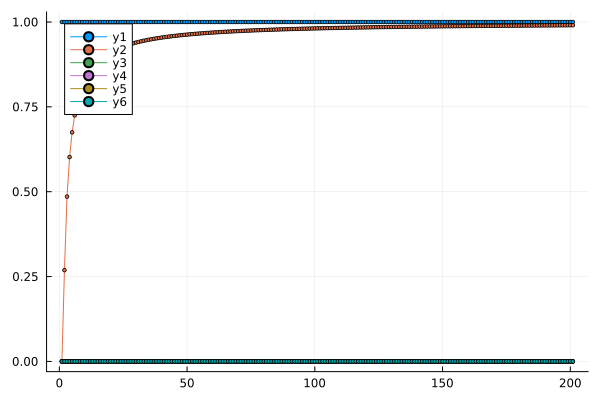

In [11]:
processed_λs = process_eigenvalues(λs, 6; tol=1e-4)
plot(processed_λs, m=2)

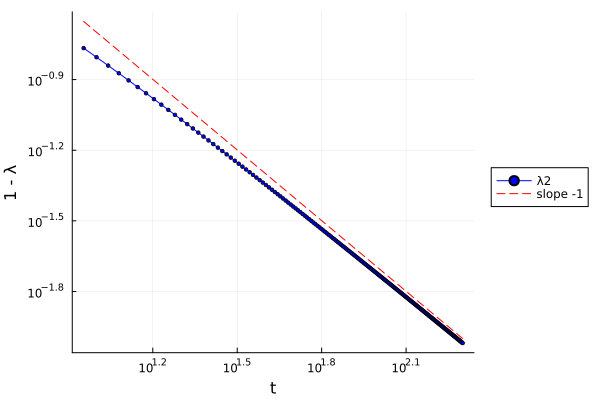

In [12]:
plt = plot()

xs = 0:200
ys = 1 .- processed_λs[:,2:end]

for i in 1:1
    plt = plot!(xs[10:end], ys[10:end, i], xscale=:log10, yscale=:log10, legend=:outerright, color=:blue,
        label="λ$(i+1)", xlabel="t", ylabel="1 - λ", m=2)
end

plot!(plt, xs[10:end], 2.0xs[10:end].^(-1), l=:dash, label="slope -1", color=:red)
# plot!(plt, xs[30:end], 3.2xs[30:end].^(-1/2), l=:dash, label="slope -1/2", color=:green)
plt

In [ ]:
# using JLD2
# jldsave("itebd_correlation_eigenvalues.jld2";  λs, processed_λs)

In [8]:
processed_λs= jldopen("itebd_correlation_eigenvalues.jld2")["processed_λs"]

201×6 Matrix{Float64}:
 1.0      0.0       0.0  0.0  0.0  0.0
 0.99994  0.268934  0.0  0.0  0.0  0.0
 1.00003  0.485652  0.0  0.0  0.0  0.0
 1.00002  0.602001  0.0  0.0  0.0  0.0
 1.00002  0.674958  0.0  0.0  0.0  0.0
 1.00001  0.725003  0.0  0.0  0.0  0.0
 1.00001  0.761464  0.0  0.0  0.0  0.0
 1.00001  0.789231  0.0  0.0  0.0  0.0
 1.00001  0.811101  0.0  0.0  0.0  0.0
 1.00001  0.828783  0.0  0.0  0.0  0.0
 ⋮                                 ⋮
 1.0      0.99004   0.0  0.0  0.0  0.0
 1.0      0.99009   0.0  0.0  0.0  0.0
 1.0      0.99014   0.0  0.0  0.0  0.0
 1.0      0.990189  0.0  0.0  0.0  0.0
 1.0      0.990238  0.0  0.0  0.0  0.0
 1.0      0.990286  0.0  0.0  0.0  0.0
 1.0      0.990334  0.0  0.0  0.0  0.0
 1.0      0.990382  0.0  0.0  0.0  0.0
 1.0      0.990429  0.0  0.0  0.0  0.0

In [17]:
using LaTeXStrings
using JLD2
using StatsBase

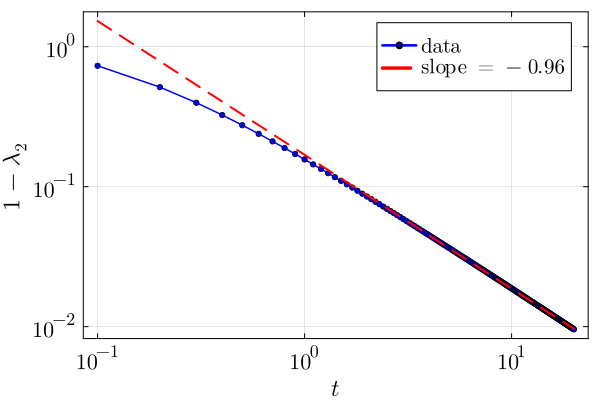

In [ ]:
plt = plot(xscale=:log10, yscale=:log10, legend=:outerright, framestyle=:box,
           xlabel=L"t", ylabel=L"1 - \lambda_2")

xs = 0:200
ys = 1 .- processed_λs[:, 2:end]

xdata = xs[2:end]
ydata = ys[2:end, 1]

plot!(plt, xdata * 0.1, ydata; color=:blue, label=L"\textrm{data}", m=(:circle, 3), lw=1.5)

t0 = 20
A = [ones(length(xdata[t0+1:end])) log10.(xdata[t0+1:end])]
b, m = A \ log10.(ydata[t0+1:end])
fit_y = 10 .^(b .+ m .* log10.(xdata))
fit_label = L"\textrm{slope\ } = %$(round(m; digits=2))"

plot!(plt, xdata * 0.1, fit_y; l=:dash, color=:red, lw=2, label=fit_label, legend=:topright, 
tickfont=font("Computer Modern", 14), xguidefontsize = 16, yguidefontsize = 16, legendfontsize = 14)
# savefig(plt, "../figs/26_01_04/itebd_gap_scaling.pdf")
plt


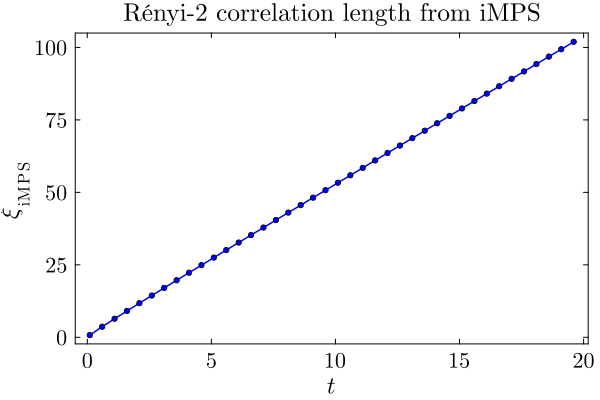

In [83]:
plt = plot( #legend=:outerright, 
framestyle=:box,
           xlabel=L"t", ylabel=L"\xi_{\textsf{iMPS}}",
           tickfont=font("Computer Modern", 14), xguidefontsize = 16, yguidefontsize = 16, legendfontsize = 14, grid=false)#, size=(400,400))

xs = 0:200
ys = -1 ./ log.(processed_λs[:, 2:end])

xdata = xs[2:5:end]
ydata = ys[2:5:end, 1]

plot!(plt, xdata * 0.1, ydata; color=:blue, 
# label=L"\textrm{data}",
label="",
m=(:circle, 3), lw=1.5, title="Rényi-2 correlation length from iMPS", titlefont=font("Computer Modern", 16))

# t0 = 0
# A = [ones(length(xdata[t0+1:5:end])) xdata[t0+1:5:end]]
# b, m = A \ ydata[t0+1:5:end]
# fit_y = b .+ m .* xdata
# fit_label = L"\textrm{slope} = %$(round(m; digits=2))"

# plot!(plt, xdata * 0.1, fit_y; l=:dash, color=:red, lw=2, label=fit_label, legend=:bottomright, 
# tickfont=font("Computer Modern", 14), xguidefontsize = 16, yguidefontsize = 16, legendfontsize = 14, grid=false)
savefig(plt, "../figs/26_01_04/itebd_gap_scaling_new.pdf")
plt


In [33]:
res = fit_y[21:end] .- ydata[21:end]
dev = ydata[21:end] .- mean(ydata[21:end])
1 - (res' * res) / (dev' * dev)  # R² value

0.9999758379218756

In [25]:
ydata

200-element Vector{Float64}:
   0.7614476477803281
   1.3845388963382386
   1.9704598939285631
   2.543849461455098
   3.1096460047744503
   3.669557492514355
   4.224829251639394
   4.776391117963
   5.324910622561306
   5.870873578507571
   ⋮
  99.89770716036338
 100.4078141277538
 100.9178922700647
 101.42794465883077
 101.93796996219997
 102.44796805541871
 102.95794504694261
 103.4678879571214
 103.97780993014655

In [34]:
t0 = 20
inds = (t0+1):length(xdata)

X = [ones(length(inds)) log10.(xdata[inds])]
z = log10.(ydata[inds])

β = X \ z
b, m = β

r = z - X*β
N = length(z)
p = 2
σ2 = sum(abs2, r) / (N - p)

Covβ = σ2 * inv(X'X)
SE_b = sqrt(Covβ[1,1])
SE_m = sqrt(Covβ[2,2])

# optional: 95% CI (normal approx; fine for N~O(100))
CI_m = (m - 1.96*SE_m, m + 1.96*SE_m)

fit_y = 10 .^(b .+ m .* log10.(xdata))

R2 = 1 - sum(abs2, r) / sum(abs2, z .- mean(z))

0.9999810413113476

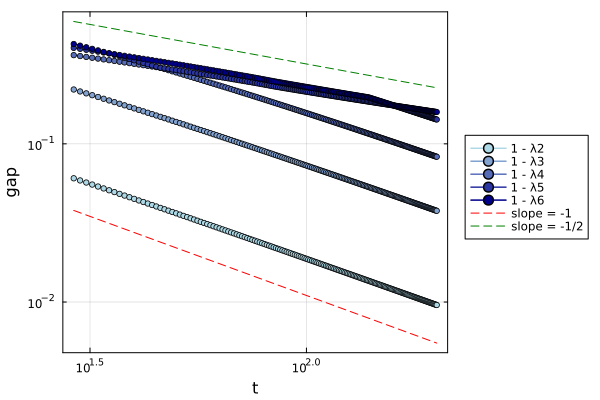

In [339]:
plt = plot(xscale=:log10, yscale=:log10, legend=:outerright, framestyle=:box,
           xlabel="t", ylabel="gap")

xs = 0:200
ys = 1 .- processed_λs[:, 2:end]

for i in 1:5
    plot!(plt, xs[30:end], ys[30:end, i];
          color=palette(:blues, 5)[i], label="1 - λ$(i+1)", m=(:circle, 3), lw=1.5)
end

plot!(plt, xs[30:end], 1.1 .* xs[30:end].^(-1); l=:dash, label="slope = -1", color=:red)
plot!(plt, xs[30:end], 3.2 .* xs[30:end].^(-1/2); l=:dash, label="slope = -1/2", color=:green)
savefig(plt, "../figs/26_01_04/itebd_gap_scaling2.pdf")
plt

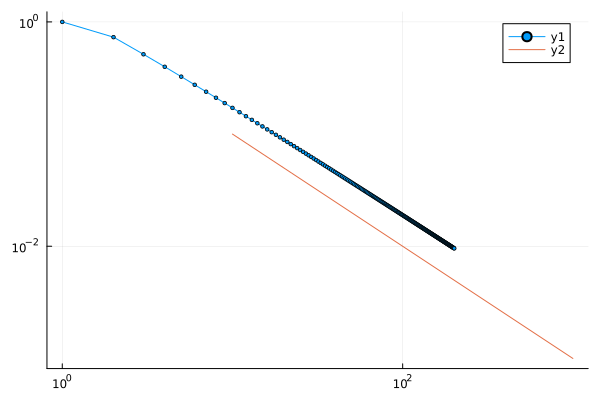

In [288]:
gap1 = processed_λs[:,1] .- processed_λs[:,2]
plot(gap1, xscale=:log10, yscale=:log10, m=2)
plot!(10:1000, collect(10:1000).^(-1))

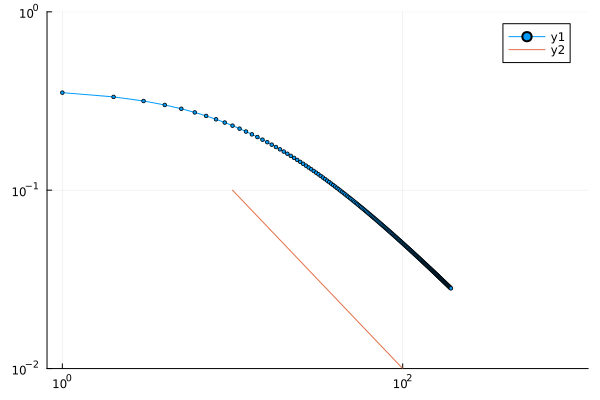

In [123]:
gap2 = processed_λs[:,2] .- processed_λs[:,3]
plot(gap2[10:end], xscale=:log10, yscale=:log10, m=2, ylims=(1e-2,1e0))
plot!(10:1000, collect(10:1000).^(-1))

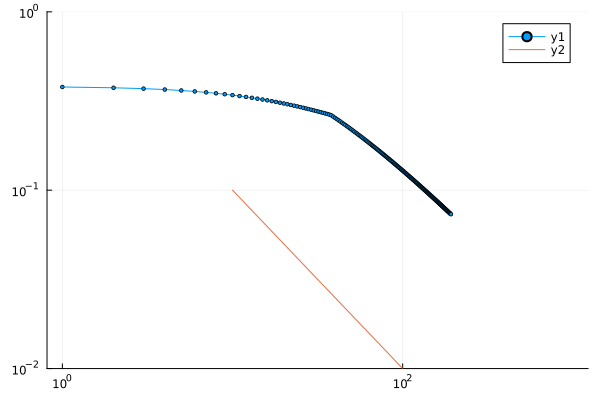

In [122]:
gap3 = processed_λs[:,2] .- processed_λs[:,4]
plot(gap3[10:end], xscale=:log10, yscale=:log10, m=2, ylims=(1e-2,1e0))
plot!(10:1000, collect(10:1000).^(-1))

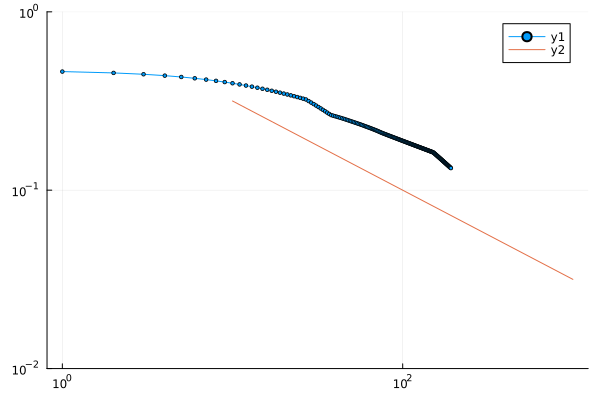

In [120]:
gap4 = processed_λs[:,2] .- processed_λs[:,5]
plot(gap4[10:end], xscale=:log10, yscale=:log10, m=2, ylims=(1e-2,1e0))
plot!(10:1000, collect(10:1000).^(-1/2))

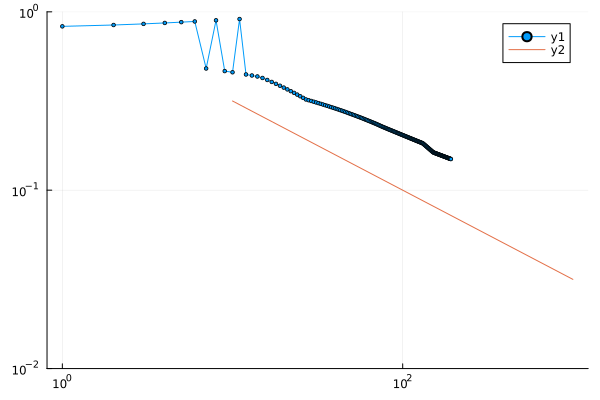

In [121]:
gap5 = processed_λs[:,2] .- processed_λs[:,6]
plot(gap5[10:end], xscale=:log10, yscale=:log10, m=2, ylims=(1e-2,1e0))
plot!(10:1000, collect(10:1000).^(-1/2))

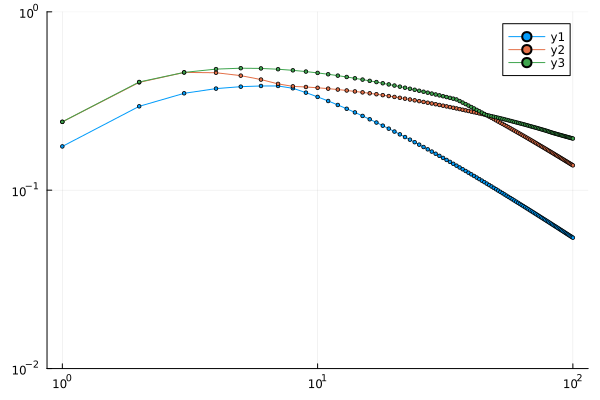

In [99]:
plot(processed_λs[2:end,2] .- processed_λs[2:end,3:end], m=2, xscale=:log10, yscale=:log10, ylims=(1e-2,1e0))

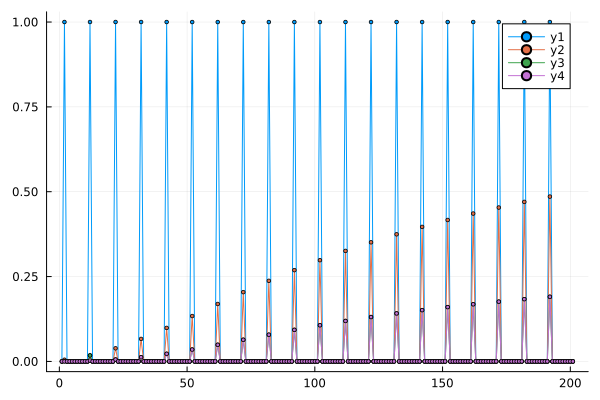

In [54]:
plot(λs, m=2)

In [50]:
function approx_unique(v::AbstractVector; tol=1e-8)
    u = []
    for x in v
        if all(abs.(x .- u) .> tol)
            push!(u, x)
        end
    end
    return u
end

[approx_unique(λs[t,:]) for t in 1:size(λs,1)]

201-element Vector{Vector{Any}}:
 [0.0]
 [1.0000243877575188, 0.004964397018876829, 0.0005191792529129943, 4.031024500671615e-16]
 [1.0000713357555406, 0.017658295468027427, 0.002492951677719387]
 [1.000090124213572, 0.03858463909503347, 0.005534109553044631, 0.005534087386893124]
 [1.0000552016426294, 0.06632389166054464, 0.01249507384328558, 0.012495005337253541]
 [0.9999884035614075, 0.09876279159972574, 0.022498509882898917]
 [0.9999300783253067, 0.1336901262085067, 0.0349712219365826]
 [0.9999018938496632, 0.16924885128485886, 0.04905044356596949]
 [0.999901691473057, 0.20411758259594784, 0.063860870158119]
 [0.999917726316818, 0.2374852751340431, 0.07867998347694077]
 ⋮
 [1.0000016088928798, 0.9117017605090143, 0.6921296413605252]
 [1.0000015963466142, 0.9121146573211697, 0.6933694254330006]
 [1.0000015839617946, 0.9125236495242817, 0.6945992255081577]
 [1.0000015717355444, 0.9129287926655212, 0.695819159352213]
 [1.0000015596650191, 0.9133301412118948, 0.6970293437769208]
 [1.00

In [30]:
transfer_spectrum(psi, 2)

2-element Vector{ComplexF64}:
  1.000004279799849 + 3.5033483823965835e-12im
 0.8433844271201713 + 1.3159014358846135e-10im

In [33]:
trmat = iTEBD.gtrm(psi,psi)
val, vec = eigsolve(trmat, 2);

In [34]:
val

2-element Vector{ComplexF64}:
 1.0000042797940507 + 7.803769892327926e-16im
 0.8433844269172392 + 9.43689570931383e-16im